In [1]:
import matplotlib.pyplot as plt
import numpy as np
from ngsolve import GridFunction
import ipywidgets as widgets
from ipywidgets import interact
from pymor.core.pickle import load

from fom import create_fom

fom = create_fom(nt=300, h=50, time=30)

# access parameter study

with open('brusselator_parameters.pkl', 'rb') as f:
    parameterstudy = load(f)

# access std snapshots

with open('std_Brusselator_snapshots.pkl', 'rb') as f:
    old_snapshots1 = load(f)
std_Brusselator_snapshots = fom.solution_space.from_numpy(old_snapshots1.to_numpy())

len(std_Brusselator_snapshots)

# access the enriched snapshots

with open('enriched_Brusselator_snapshots_DaDt.pkl', 'rb') as f:
    snapshots_enriched_DaDt = load(f)

with open('enriched_Brusselator_snapshots_DtDa.pkl', 'rb') as f:
    snapshots_enriched_DtDa = load(f)

print(f"Loaded std snapshots: {len(std_Brusselator_snapshots)}")
print(f"Loaded DaDt snapshots: {len(snapshots_enriched_DaDt)}")
print(f"Loaded DtDa snapshots: {len(snapshots_enriched_DtDa)}")

Loaded std snapshots: 260
Loaded DaDt snapshots: 260
Loaded DtDa snapshots: 260


In [2]:
# std POD

r_std = 60

from pymor.algorithms.pod import pod
std_pod_basis, std_pod_singular_values = pod(std_Brusselator_snapshots,
                                     product=fom.products['h1_0_semi'],
                                     method= 'qr_svd',
                                     modes=r_std,
                                     rtol=1e-12,   
                                     atol=0.0 
                                    )
len(std_pod_basis)

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

c:\Users\laraf\anaconda3\Lib\site-packages\pymor\bindings\scipy.py:31: UserWarning: Your SciPy installation seems to be using MKL as LAPACK library.
To avoid stability issues on Windows, we use gesdd instead of gesvd
for SVD computation. This may lead to reduced numerical accuracy.
See https://github.com/pymor/pymor/issues/2391 for further discussion.
To silence this warning, set the pymor.bindings.scipy.svd_lapack_driver.driver
default to either "gesvd" or "gesdd".
  warn('Your SciPy installation seems to be using MKL as LAPACK library.\n'


60

In [3]:
# enriched POD with DtDa

r_std = 60

snapshots_enriched_DtDa = fom.solution_space.from_numpy(snapshots_enriched_DtDa.to_numpy())

from pymor.algorithms.pod import pod
enriched_DtDa_pod_basis, enriched_DtDa_pod_singular_values = pod(snapshots_enriched_DtDa,
                                     product=fom.products['h1_0_semi'],
                                     modes=r_std, 
                                     method= 'qr_svd', 
                                     rtol=1e-11,   
                                     atol=1e-10,
                                     #orth_tol= 1e-8
                                    )
len(enriched_DtDa_pod_basis)

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

60

In [4]:
# enriched POD with DaDt

r_std = 60

snapshots_enriched_DaDt = fom.solution_space.from_numpy(snapshots_enriched_DaDt.to_numpy())

from pymor.algorithms.pod import pod
enriched_DaDt_pod_basis, enriched_DaDt_pod_singular_values = pod(snapshots_enriched_DaDt,
                                     product=fom.products['h1_0_semi'],
                                     modes=r_std, 
                                     method= 'qr_svd', 
                                     rtol=1e-14,   
                                     atol=1e-14,
                                     #orth_tol= 1e-8
                                    )
len(enriched_DaDt_pod_basis)

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

60

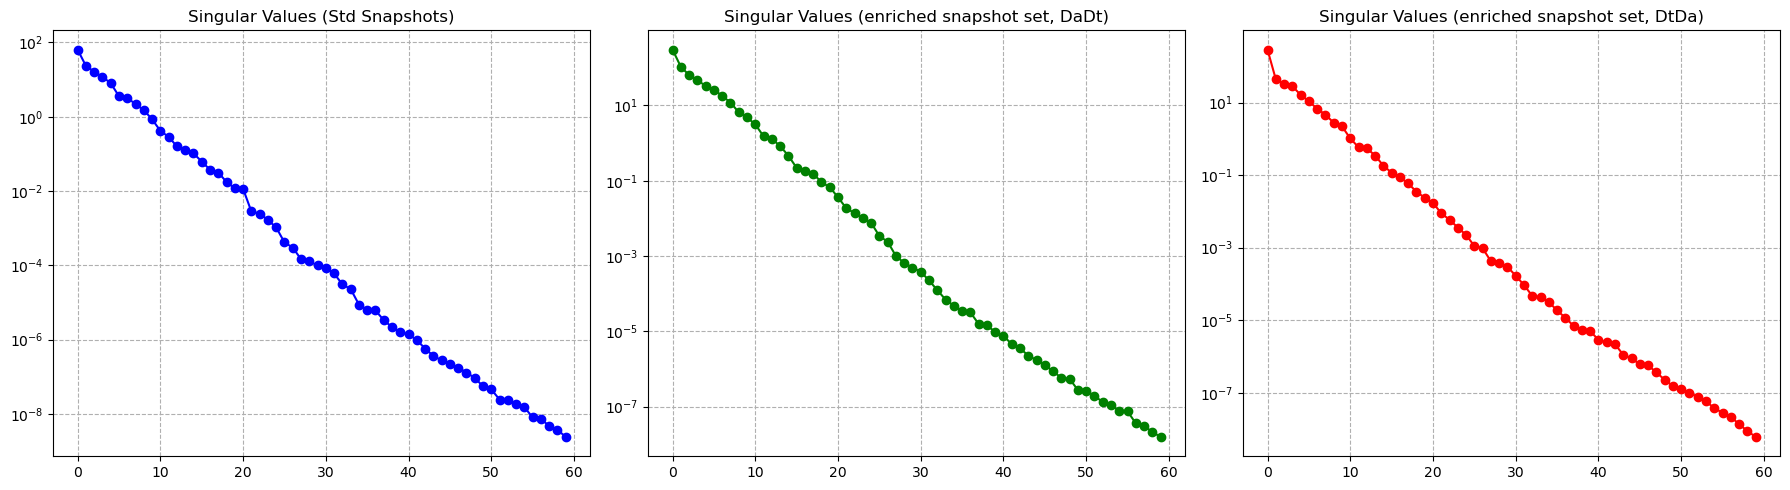

In [5]:
# plot the singular values

import matplotlib.pyplot as plt

fig, axs = plt.subplots(1,3, figsize=(18, 5))

axs[0].semilogy(std_pod_singular_values, marker='o', color='blue')
axs[0].set_title("Singular Values (Std Snapshots)")
axs[0].grid(True, which="both", ls="--")

axs[1].semilogy(enriched_DaDt_pod_singular_values, marker='o', color='green')
axs[1].set_title("Singular Values (enriched snapshot set, DaDt)")
axs[1].grid(True, which="both", ls="--")

axs[2].semilogy(enriched_DtDa_pod_singular_values, marker='o', color='red')
axs[2].set_title("Singular Values (enriched snapshot set, DtDa)")
axs[2].grid(True, which="both", ls="--")

plt.tight_layout()
plt.show()

In [6]:
# construct std POD-ROM 

from pymor.reductors.parabolic import ParabolicRBReductor

r=20

beta= 3.5 # chose sample parameter here

data = parameterstudy[beta]
T_per = data['period']
u0_array = data['initial_data']

fom = create_fom(nt=300, h=50, time=T_per, initial_array=u0_array) 

#fom = create_fom(nt=700, h=50, time=30, initial_array=u0_array) 

RB_adapted = fom.solution_space.from_numpy(std_pod_basis[:r].to_numpy())

reductor_std = ParabolicRBReductor(
       fom=fom,
       RB=RB_adapted,
       product=fom.h1_0_semi_product,
       coercivity_estimator=None,
       check_orthonormality=False,
       check_tol=1e-10
   )

rom_std_r = reductor_std.reduce()   # create r-dim rom
u_rom_std = rom_std_r.solve(beta) # solve rom for this mu in low dim
std_rom_rec = reductor_std.reconstruct(u_rom_std) # back to high dim

len(std_rom_rec)


Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

301

In [7]:
# construct enriched POD-ROM (DtDa)

RB_adapted = fom.solution_space.from_numpy(enriched_DtDa_pod_basis[:r].to_numpy())

reductor_DtDa = ParabolicRBReductor(
       fom=fom,
       RB=RB_adapted,
       product=fom.h1_0_semi_product,
       coercivity_estimator=None,
       check_orthonormality=False,
       check_tol=1e-10
   )

rom_DtDa_r = reductor_DtDa.reduce()         # create r-dim rom
u_rom_DtDa = rom_DtDa_r.solve(beta)         # solve rom for this mu in low dim
DtDa_rom_rec = reductor_DtDa.reconstruct(u_rom_DtDa) # back to high dim

len(DtDa_rom_rec)

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

301

In [8]:
# construct enriched POD-ROM (DaDt)

RB_adapted = fom.solution_space.from_numpy(enriched_DaDt_pod_basis[:r].to_numpy())

reductor_DaDt = ParabolicRBReductor(
       fom=fom,
       RB=RB_adapted,
       product=fom.h1_0_semi_product,
       coercivity_estimator=None,
       check_orthonormality=False,
       check_tol=1e-10
   )

rom_DaDt_r = reductor_DaDt.reduce()         # create r-dim rom
u_rom_DaDt = rom_DaDt_r.solve(beta)         # solve rom for this mu in low dim
DaDt_rom_rec = reductor_DaDt.reconstruct(u_rom_DaDt) # back to high dim

len(DaDt_rom_rec)

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

301

In [9]:
# compute fom solution for beta as a reference for the error analysis
    
U_trajectory = fom.solve(beta)

len(U_trajectory)

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

301

In [10]:
# V_h = fom.operator.V_h
# mesh = V_h.mesh

# num_x_points = 200
# num_t_points = len(std_rom_rec) 

# x_werte = np.linspace(0, 1, num_x_points)
# t_werte = np.linspace(0, fom.T, num_t_points)
# T, X = np.meshgrid(t_werte, x_werte)

# u_matrix_fom = np.zeros((num_x_points, num_t_points))
# v_matrix_fom = np.zeros((num_x_points, num_t_points))

# u_matrix_rom_std = np.zeros((num_x_points, num_t_points))
# v_matrix_rom_std = np.zeros((num_x_points, num_t_points))

# u_matrix_rom_enr = np.zeros((num_x_points, num_t_points))
# v_matrix_rom_enr = np.zeros((num_x_points, num_t_points))

# gfu_plot = GridFunction(V_h)

# for t_idx in range(num_t_points):
#     vec_pymor_fom = U_trajectory[t_idx].vectors[0].real_part
#     gfu_plot.vec.data = vec_pymor_fom.impl.vec 
#     u_matrix_fom[:, t_idx] = [gfu_plot.components[0](mesh(x)) for x in x_werte]
#     v_matrix_fom[:, t_idx] = [gfu_plot.components[1](mesh(x)) for x in x_werte]

#     vec_pymor_rom_std = std_rom_rec[t_idx].vectors[0].real_part
#     gfu_plot.vec.data = vec_pymor_rom_std.impl.vec 
#     u_matrix_rom_std[:, t_idx] = [gfu_plot.components[0](mesh(x)) for x in x_werte]
#     v_matrix_rom_std[:, t_idx] = [gfu_plot.components[1](mesh(x)) for x in x_werte]

#     vec_pymor_rom_enr = DaDt_rom_rec[t_idx].vectors[0].real_part
#     gfu_plot.vec.data = vec_pymor_rom_enr.impl.vec 
#     u_matrix_rom_enr[:, t_idx] = [gfu_plot.components[0](mesh(x)) for x in x_werte]
#     v_matrix_rom_enr[:, t_idx] = [gfu_plot.components[1](mesh(x)) for x in x_werte]


# fig, axs = plt.subplots(2, 3, figsize=(24, 12))

# c1 = axs[0, 0].pcolormesh(T, X, u_matrix_fom, cmap='viridis', shading='auto', vmin=None, vmax=None)
# axs[0, 0].set_title(f"FOM u | {beta}")
# axs[0, 0].set_xlabel("t")
# axs[0, 0].set_ylabel("x")
# fig.colorbar(c1, ax=axs[0, 0], label="")

# c2 = axs[0, 1].pcolormesh(T, X, u_matrix_rom_std, cmap='viridis', shading='auto', vmin=None, vmax=None)
# axs[0, 1].set_title(f"Std ROM u | {beta}, r={r}")
# axs[0, 1].set_xlabel("t")
# axs[0, 1].set_ylabel("x")
# fig.colorbar(c2, ax=axs[0, 1], label="")

# c3 = axs[0, 2].pcolormesh(T, X, u_matrix_rom_enr, cmap='viridis', shading='auto', vmin=None, vmax=None)
# axs[0, 2].set_title(f"Enriched ROM u | {beta}, r={r}")
# axs[0, 2].set_xlabel("t")
# axs[0, 2].set_ylabel("x")
# fig.colorbar(c3, ax=axs[0, 2], label="")

# c4 = axs[1, 0].pcolormesh(T, X, v_matrix_fom, cmap='magma', shading='auto', vmin=None, vmax=None)
# axs[1, 0].set_title(f"FOM v | {beta}")
# axs[1, 0].set_xlabel("t")
# axs[1, 0].set_ylabel("x")
# fig.colorbar(c4, ax=axs[1, 0], label="")

# c5 = axs[1, 1].pcolormesh(T, X, v_matrix_rom_std, cmap='magma', shading='auto', vmin=None, vmax=None)
# axs[1, 1].set_title(f"Std ROM v | {beta}, r={r}")
# axs[1, 1].set_xlabel("t")
# axs[1, 1].set_ylabel("x")
# fig.colorbar(c5, ax=axs[1, 1], label="")

# c6 = axs[1, 2].pcolormesh(T, X, v_matrix_rom_enr, cmap='magma', shading='auto', vmin=None, vmax=None)
# axs[1, 2].set_title(f"Enriched ROM v | {beta}, r={r}")
# axs[1, 2].set_xlabel("t")
# axs[1, 2].set_ylabel("x")
# fig.colorbar(c6, ax=axs[1, 2], label="")

# plt.savefig('picture.pdf', bbox_inches='tight') 

# plt.tight_layout()
# plt.show()

In [11]:
# #  now we consider different values for r and max over t, still one parameter, std ROM

# import gc 

# max_r = 22
# r_values = range(1, max_r + 1, 5) 
# errors_std = []
# errors_proj_std = []

# for r in r_values:

#         print(f"start{r}")
 
#         rom_r_std = reductor_std.reduce(dims={'RB': r})  # construct ROM with r modes
#         u_rom_std = rom_r_std.solve(beta) # solve for testmu
#         u_rec_std = reductor_std.reconstruct(u_rom_std) # reconstruct to high dim
    
#         err = np.max((U_trajectory - u_rec_std).norm(fom.h1_0_semi_product))   # consider error max{t}\norm{(u_h - u_r^std)}
#         errors_std.append(err)

#         # for std
#         RB_adapted = fom.solution_space.from_numpy(std_pod_basis[:r].to_numpy())

#         coeffs_std = fom.products['h1_0_semi'].apply2(RB_adapted, U_trajectory) 
#         u_projected_std = RB_adapted.lincomb(coeffs_std)              
    
#         error_proj_std_max = np.max((U_trajectory - u_projected_std).norm(fom.products['h1_0_semi'])) # (u_h - Pr(u_h)) max over t
        
#         errors_proj_std.append(error_proj_std_max)
    
#         filename_err_std = f"errors_std_mu_{beta}.npy"
#         filename_proj_std = f"proj_std_mu_{beta}.npy"

#         np.save(filename_err_std, np.array(errors_std))
#         np.save(filename_proj_std, np.array(errors_proj_std))
    
#         del u_rec_std, u_rom_std
#         del u_projected_std
#         gc.collect()

In [12]:
# # same loop for the enriched POD-ROM (DaDt)

# errors_U = []
# errors_proj_U = []

# for r in r_values:

#         print(f"start{r}")

#         rom_r_U = reductor_DaDt.reduce(dims={'RB': r}) # construct ROM with r modes
#         u_rom_U = rom_r_U.solve(beta) # solve for testmu
#         u_rec_U = reductor_DaDt.reconstruct(u_rom_U) # reconstruct to high dim
    
       
#         err = np.max((U_trajectory - u_rec_U).norm(fom.h1_0_semi_product))   # consider error max{t}\norm{(u_h - u_r^std)}
#         errors_U.append(err)

#         RB_adapted = fom.solution_space.from_numpy(enriched_DaDt_pod_basis[:r].to_numpy())
#         coeffs_U = fom.products['h1_0_semi'].apply2(RB_adapted, U_trajectory) 
#         u_projected_U = RB_adapted.lincomb(coeffs_U)              
    
#         error_proj_U_max = np.max((U_trajectory - u_projected_U).norm(fom.products['h1_0_semi'])) # (u_h - Pr(u_h)) max over t
        
#         errors_proj_U.append(error_proj_U_max)

#         filename_err = f"errors_U_mu_{beta}.npy"
#         filename_proj = f"proj_U_mu_{beta}.npy"

#         np.save(filename_err, np.array(errors_U))
#         np.save(filename_proj, np.array(errors_proj_U))
    
#         del u_rec_U 
#         del u_rom_U
#         del u_projected_U
#         gc.collect()
    
    

In [13]:
# # plot both together

# import matplotlib.pyplot as plt

# errors_std = np.load(f"errors_std_mu_{beta}.npy")
# errors_proj_std = np.load(f"proj_std_mu_{beta}.npy")

# errors_U = np.load(f"errors_U_mu_{beta}.npy")
# errors_proj_U = np.load(f"proj_U_mu_{beta}.npy")
# max_r = 22
# r_values = range(1, max_r + 1, 5) 

# r_values = r_values[:-1]
# errors_std = errors_std[:-1]
# errors_proj_std = errors_proj_std[:-1]
# errors_U = errors_U[:-1]
# errors_proj_U = errors_proj_U[:-1]

# plt.figure(figsize=(10, 7))
# plt.semilogy(r_values, errors_std, 'r-s', linewidth=2, label='std POD-ROM')
# plt.semilogy(r_values, errors_proj_std, 'r--s', alpha=0.7, label='proj. Error (std)')
# plt.semilogy(r_values, errors_U, 'b-o', linewidth=2, label='enriched POD-ROM')
# plt.semilogy(r_values, errors_proj_U, 'b--o', alpha=0.7, label='proj. Error (enriched)')
# plt.xlabel('modes r', fontsize=12)
# plt.ylabel(r"$max_{t}$ Error (H1-Seminorm)")
# plt.title(fr"Comparison of convergence ($\beta$={beta})", fontsize=14)
# plt.legend(fontsize=10, loc='best')
# plt.tight_layout()
# plt.show()

In [14]:
# import gc 
# import numpy as np

# max_r = 22
# r_values = range(1, max_r + 1, 5) 

# errors_U2 = []
# errors_proj_U2 = []

# for r in r_values:

#         print(f"start r={r}")

#         rom_r_U2 = reductor_DtDa.reduce(dims={'RB': r}) 
#         u_rom_U2 = rom_r_U2.solve(beta) 
#         u_rec_U2 = reductor_DtDa.reconstruct(u_rom_U2) 
    
#         err = np.max((U_trajectory - u_rec_U2).norm(fom.products['h1_0_semi']))   
#         errors_U2.append(err)

#         RB_adapted = fom.solution_space.from_numpy(enriched_DtDa_pod_basis[:r].to_numpy())
#         coeffs_U2 = fom.products['h1_0_semi'].apply2(RB_adapted, U_trajectory) 

#         u_projected_U2 = RB_adapted.lincomb(coeffs_U2)              
    
#         error_proj_U2_max = np.max((U_trajectory - u_projected_U2).norm(fom.products['h1_0_semi'])) 
        
#         errors_proj_U2.append(error_proj_U2_max)

#         filename_err = f"errors_U2_mu_{beta}.npy"
#         filename_proj = f"proj_U2_mu_{beta}.npy"

#         np.save(filename_err, np.array(errors_U2))
#         np.save(filename_proj, np.array(errors_proj_U2))
    
#         del u_rec_U2 
#         del u_rom_U2
#         del u_projected_U2
#         gc.collect()

In [15]:
# # plot both together, DtDa

# import matplotlib.pyplot as plt

# errors_std = np.load(f"errors_std_mu_{beta}.npy")
# errors_proj_std = np.load(f"proj_std_mu_{beta}.npy")

# errors_U = np.load(f"errors_U2_mu_{beta}.npy")
# errors_proj_U = np.load(f"proj_U2_mu_{beta}.npy")
# max_r = 22
# r_values = range(1, max_r + 1, 5) 

# r_values = r_values[:-1]
# errors_std = errors_std[:-1]
# errors_proj_std = errors_proj_std[:-1]
# errors_U = errors_U[:-1]
# errors_proj_U = errors_proj_U[:-1]

# plt.figure(figsize=(10, 7))
# plt.semilogy(r_values, errors_std, 'r-s', linewidth=2, label='std POD-ROM')
# plt.semilogy(r_values, errors_proj_std, 'r--s', alpha=0.7, label='proj. Error (std)')
# plt.semilogy(r_values, errors_U, 'b-o', linewidth=2, label='enriched POD-ROM')
# plt.semilogy(r_values, errors_proj_U, 'b--o', alpha=0.7, label='proj. Error (enriched)')
# plt.xlabel('modes r', fontsize=12)
# plt.ylabel(r"$max_{t}$ Error (H1-Seminorm)")
# plt.title(fr"Comparison of convergence ($\beta$={beta})", fontsize=14)
# plt.legend(fontsize=10, loc='best')
# plt.tight_layout()
# plt.show()

In [16]:
r=15

# compute std ROM solution
rom_std_r = reductor_std.reduce(dims={'RB': r})   # create r-dim rom
u_rom_std = rom_std_r.solve(beta) 
u_rec_std = reductor_std.reconstruct(u_rom_std) 

# compute enriched ROM solution (DaDt)
rom_U_r = reductor_DaDt.reduce(dims={'RB': r})
u_rom_U = rom_U_r.solve(beta) 
u_rec_U = reductor_DaDt.reconstruct(u_rom_U) 

# compute enriched ROM solution (DtDa)
rom_U_r2 = reductor_DtDa.reduce(dims={'RB': r})
u_rom_U2 = rom_U_r2.solve(beta)  
u_rec_U2 = reductor_DtDa.reconstruct(u_rom_U2) 

# Error calculation
error_rom_U = (U_trajectory - u_rec_U).norm(fom.products['h1_0_semi'])  
error_rom_U2 = (U_trajectory - u_rec_U2).norm(fom.products['h1_0_semi']) 
error_rom_std = (U_trajectory - u_rec_std).norm(fom.products['h1_0_semi']) 

# for the error anylysis: (u_h - u_r) = (u_h - Pr(u_h)) + (Pr(u_h) - u_r))

# std POD-ROM
RB_adapted_std = fom.solution_space.from_numpy(std_pod_basis[:r].to_numpy())
coeffs_std = fom.products['h1_0_semi'].apply2(RB_adapted_std, U_trajectory) 
u_projected_std = RB_adapted_std.lincomb(coeffs_std) 
error_proj_std = (U_trajectory - u_projected_std).norm(fom.products['h1_0_semi']) 

# enriched POD-ROM (DaDt)
RB_adapted_U = fom.solution_space.from_numpy(enriched_DaDt_pod_basis[:r].to_numpy())
coeffs_U = fom.products['h1_0_semi'].apply2(RB_adapted_U, U_trajectory) 
u_projected_U = RB_adapted_U.lincomb(coeffs_U)        
error_proj_U = (U_trajectory - u_projected_U).norm(fom.products['h1_0_semi']) 

# enriched POD-ROM (DtDa)
RB_adapted_U2 = fom.solution_space.from_numpy(enriched_DtDa_pod_basis[:r].to_numpy())
coeffs_U2 = fom.products['h1_0_semi'].apply2(RB_adapted_U2, U_trajectory) 
u_projected_U2 = RB_adapted_U2.lincomb(coeffs_U2) 
error_proj_U2 = (U_trajectory - u_projected_U2).norm(fom.products['h1_0_semi'])

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

In [17]:
# times = np.linspace(0, T_per, 300 + 1)

# plt.figure(figsize=(9, 6))

# plt.semilogy(times, error_rom_std, color='red', label='Standard POD-ROM')
# plt.semilogy(times, error_rom_U, color='blue', label=fr'Enriched POD-ROM ($D^\alpha D^t$)')
# plt.semilogy(times, error_rom_U2, color='green', label=fr'Enriched POD-ROM ($D^t D^\alpha$)')

# plt.semilogy(times, error_proj_std, color='red', linestyle='--', alpha=0.7, label='Proj. Error')
# plt.semilogy(times, error_proj_U, color='blue', linestyle='--', alpha=0.7, label='Proj. Error')
# plt.semilogy(times, error_proj_U2, color='green', linestyle='--', alpha=0.7, label='Proj. Error')

# plt.title(fr'ROM-error over time for $\beta$={beta}, including projection error (r={r})', fontsize=14)
# plt.xlabel('time')
# plt.ylabel(r'$H^1$-Seminorm Error')
# plt.legend(loc='best', ncol=2, fontsize=9)
# #plt.grid(True, which="both", ls="--", alpha=0.4)

# #plt.savefig('Brusselator_325.pdf', bbox_inches='tight')

# plt.tight_layout()
# plt.show()

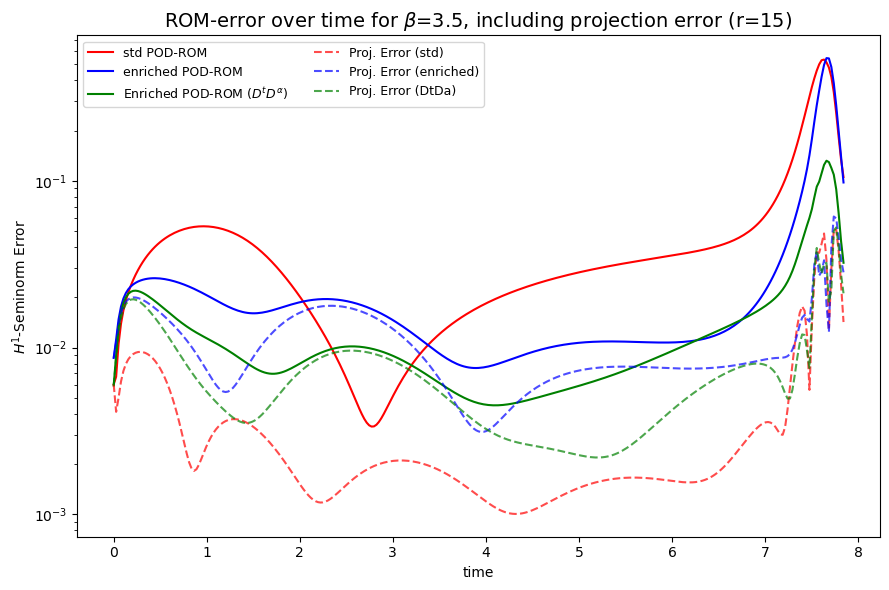

In [18]:
times = np.linspace(0, T_per, 300 + 1)

plt.figure(figsize=(9, 6))

plt.semilogy(times, error_rom_std, color='red', label='std POD-ROM')
plt.semilogy(times, error_rom_U, color='blue', label=fr'enriched POD-ROM')
plt.semilogy(times, error_rom_U2, color='green', label=fr'Enriched POD-ROM ($D^t D^\alpha$)')

plt.semilogy(times, error_proj_std, color='red', linestyle='--', alpha=0.7, label='Proj. Error (std)')
plt.semilogy(times, error_proj_U, color='blue', linestyle='--', alpha=0.7, label='Proj. Error (enriched)')
plt.semilogy(times, error_proj_U2, color='green', linestyle='--', alpha=0.7, label='Proj. Error (DtDa)')

plt.title(fr'ROM-error over time for $\beta$={beta}, including projection error (r={r})', fontsize=14)
plt.xlabel('time')
plt.ylabel(r'$H^1$-Seminorm Error')
plt.legend(loc='best', ncol=2, fontsize=9)
#plt.grid(True, which="both", ls="--", alpha=0.4)

plt.savefig('Brusselator_green35.pdf', bbox_inches='tight')

plt.tight_layout()
plt.show()